# Challenge 11: Ethics in AI Investigation

Mission: Investigate model bias, measure fairness disparities, and propose solutions.

Complete each TODO in order.

## 1. Setup: Imports

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print('Imports loaded')

Imports loaded


## 2. Load and inspect data

TODO:
1. Load hiring_bias_dataset.csv
2. Display first rows and shape
3. Check demographic breakdown

In [27]:
# Load dataset and apply light cleaning so downstream cells run reliably
file_path = "data/hiring_bias_dataset.csv"
df = pd.read_csv(file_path)

# Normalize column names and key categorical labels
df.columns = df.columns.str.strip()
df["gender"] = df["gender"].astype(str).str.strip().str.title()

# Ensure target/prediction columns are numeric binary values
for col in ["actual_hired", "model_predicted_hired"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=["actual_hired", "model_predicted_hired", "gender"]).copy()
df["actual_hired"] = df["actual_hired"].astype(int).clip(0, 1)
df["model_predicted_hired"] = df["model_predicted_hired"].astype(int).clip(0, 1)

print(df.head())
print(f"\nShape: {df.shape}")
print("\nColumns:", list(df.columns))

print("\nGender breakdown:")
print(df["gender"].value_counts(dropna=False))

   candidate_id  gender  years_experience  resume_score  interview_score  \
0          1492    Male                 9          65.0             34.8   
1          1419  Female                 6          76.1             75.5   
2          1252    Male                 5          94.0            100.0   
3          1104    Male                 2          75.8             91.0   
4          1176  Female                11          80.9             79.9   

   actual_hired  model_predicted_hired  
0             0                      0  
1             1                      1  
2             1                      1  
3             0                      1  
4             1                      1  

Shape: (500, 7)

Columns: ['candidate_id', 'gender', 'years_experience', 'resume_score', 'interview_score', 'actual_hired', 'model_predicted_hired']

Gender breakdown:
Male      250
Female    250
Name: gender, dtype: int64


## 3. Split by demographic group and explore

TODO:
- Split data by gender
- Show actual hiring rate and model prediction rate per group
- Note any surface-level disparities

In [28]:
# Split by gender and inspect actual vs predicted hiring rates
female_data = df[df["gender"] == "Female"].copy()
male_data = df[df["gender"] == "Male"].copy()

print(f"Female candidates: {len(female_data)}")
print(f"Male candidates: {len(male_data)}")

group_rates = (
    df.groupby("gender")[["actual_hired", "model_predicted_hired"]]
    .mean()
    .rename(
        columns={
            "actual_hired": "actual_hiring_rate",
            "model_predicted_hired": "predicted_hiring_rate",
        }
    )
)
group_rates["rate_gap_pct_points"] = (
    (group_rates["predicted_hiring_rate"] - group_rates["actual_hiring_rate"]) * 100
).round(2)

print("\nHiring rates by group:")
print(group_rates.round(3))

Female candidates: 250
Male candidates: 250

Hiring rates by group:
        actual_hiring_rate  predicted_hiring_rate  rate_gap_pct_points
gender                                                                
Female               0.492                  0.420                 -7.2
Male                 0.500                  0.508                  0.8


## 4. Calculate confusion matrices per group

TODO:
- For each gender group, build confusion matrix
- Calculate TP, FP, FN, TN counts

In [29]:
# Build confusion matrices and key performance counts per group
def compute_confusion_metrics(group_df, group_name):
    y_true = group_df["actual_hired"]
    y_pred = group_df["model_predicted_hired"]

    # Force 2x2 output even if one class is missing
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tpr
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
    selection_rate = y_pred.mean()
    base_rate = y_true.mean()

    print(f"\n{group_name} confusion matrix counts")
    print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")
    print(f"TPR={tpr:.3f}, FPR={fpr:.3f}, Precision={precision:.3f}, Accuracy={accuracy:.3f}")

    return {
        "group": group_name,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "TPR": tpr,
        "FPR": fpr,
        "precision": precision,
        "recall": recall,
        "accuracy": accuracy,
        "selection_rate": selection_rate,
        "base_rate": base_rate,
    }

metrics_female = compute_confusion_metrics(female_data, "Female")
metrics_male = compute_confusion_metrics(male_data, "Male")

confusion_matrices = {
    "Female": confusion_matrix(
        female_data["actual_hired"], female_data["model_predicted_hired"], labels=[0, 1]
    ),
    "Male": confusion_matrix(
        male_data["actual_hired"], male_data["model_predicted_hired"], labels=[0, 1]
    ),
}


Female confusion matrix counts
TP=77, FP=28, FN=46, TN=99
TPR=0.626, FPR=0.220, Precision=0.733, Accuracy=0.704

Male confusion matrix counts
TP=88, FP=39, FN=37, TN=86
TPR=0.704, FPR=0.312, Precision=0.693, Accuracy=0.696


## 5. Calculate fairness metrics per group

TODO:
- True Positive Rate (TPR / sensitivity / recall)
- False Positive Rate (FPR)
- Precision per group
- Create a summary table

In [30]:
# Create fairness summary metrics table
metrics_df = pd.DataFrame([metrics_female, metrics_male]).set_index("group")
cols = [
    "TP", "FP", "FN", "TN",
    "TPR", "FPR", "precision", "recall", "accuracy",
    "selection_rate", "base_rate",
]

print("Fairness/performance summary by gender:")
print(metrics_df[cols].round(3))

Fairness/performance summary by gender:
        TP  FP  FN  TN    TPR    FPR  precision  recall  accuracy  \
group                                                               
Female  77  28  46  99  0.626  0.220      0.733   0.626     0.704   
Male    88  39  37  86  0.704  0.312      0.693   0.704     0.696   

        selection_rate  base_rate  
group                              
Female           0.420      0.492  
Male             0.508      0.500  


## 6. Check demographic parity

TODO:
- Calculate selection rate (% predicted as 'hired') per group
- Is the difference > 5%? (common fairness threshold)
- Document finding

In [31]:
# Demographic parity: compare selection rates across groups
dp_threshold = 0.05  # 5 percentage points

selection_gap = metrics_df["selection_rate"].max() - metrics_df["selection_rate"].min()
dp_violated = selection_gap > dp_threshold

print("Selection rates by group:")
for g, val in metrics_df["selection_rate"].items():
    print(f"  {g}: {val:.2%}")

print(f"\nDemographic parity gap: {selection_gap:.2%}")
print(f"Threshold: {dp_threshold:.0%}")
print("Demographic parity violated:", dp_violated)

Selection rates by group:
  Female: 42.00%
  Male: 50.80%

Demographic parity gap: 8.80%
Threshold: 5%
Demographic parity violated: True


## 7. Check equalized odds

TODO:
- Compare TPR across groups: is difference > 5%?
- Compare FPR across groups: is difference > 5%?
- Which metric is violated (TPR, FPR, or both)?

In [32]:
# Equalized odds: compare TPR and FPR gaps across groups
eo_threshold = 0.05  # 5 percentage points

tpr_gap = metrics_df["TPR"].max() - metrics_df["TPR"].min()
fpr_gap = metrics_df["FPR"].max() - metrics_df["FPR"].min()

tpr_violated = tpr_gap > eo_threshold
fpr_violated = fpr_gap > eo_threshold

print(f"TPR gap: {tpr_gap:.2%} | Violated (>5%): {tpr_violated}")
print(f"FPR gap: {fpr_gap:.2%} | Violated (>5%): {fpr_violated}")

if tpr_violated or fpr_violated:
    violated_parts = []
    if tpr_violated:
        violated_parts.append("TPR")
    if fpr_violated:
        violated_parts.append("FPR")
    print("Equalized odds violated on:", ", ".join(violated_parts))
else:
    print("Equalized odds not violated at the 5% threshold.")

TPR gap: 7.80% | Violated (>5%): True
FPR gap: 9.15% | Violated (>5%): True
Equalized odds violated on: TPR, FPR


## 8. Visualize TPR/FPR disparity

TODO:
- Bar chart: TPR by gender
- Bar chart: FPR by gender
- Highlight which group is disadvantaged

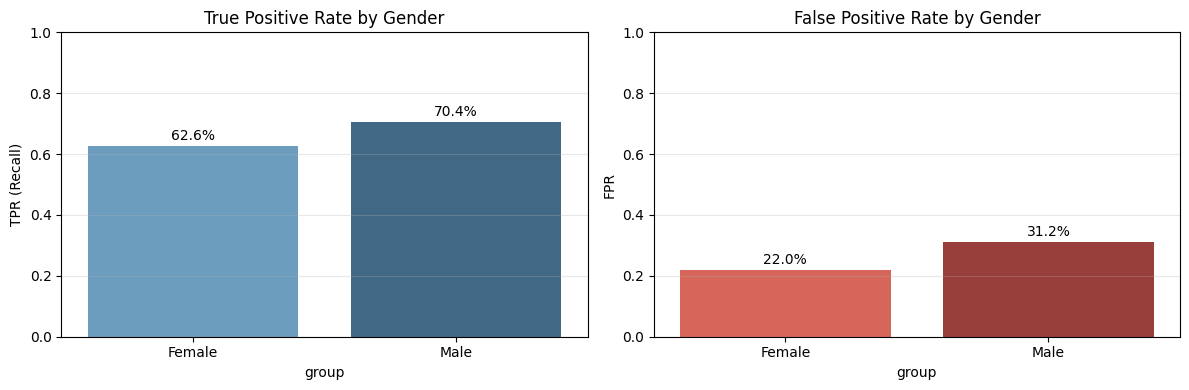

Lower TPR indicates the disadvantaged group for missed qualified candidates.


In [33]:
# Visualize TPR and FPR disparities by gender
plot_df = metrics_df.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=plot_df, x="group", y="TPR", hue="group", dodge=False, legend=False,
    ax=axes[0], palette="Blues_d"
 )
axes[0].set_title("True Positive Rate by Gender")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("TPR (Recall)")
axes[0].grid(True, axis="y", alpha=0.3)
for i, v in enumerate(plot_df["TPR"]):
    axes[0].text(i, v + 0.02, f"{v:.1%}", ha="center")

sns.barplot(
    data=plot_df, x="group", y="FPR", hue="group", dodge=False, legend=False,
    ax=axes[1], palette="Reds_d"
 )
axes[1].set_title("False Positive Rate by Gender")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("FPR")
axes[1].grid(True, axis="y", alpha=0.3)
for i, v in enumerate(plot_df["FPR"]):
    axes[1].text(i, v + 0.02, f"{v:.1%}", ha="center")

plt.tight_layout()
plt.show()

print("Lower TPR indicates the disadvantaged group for missed qualified candidates.")

## 9. Confusion matrix heatmaps

TODO:
- Side-by-side heatmaps of confusion matrices per group
- Show patterns visually

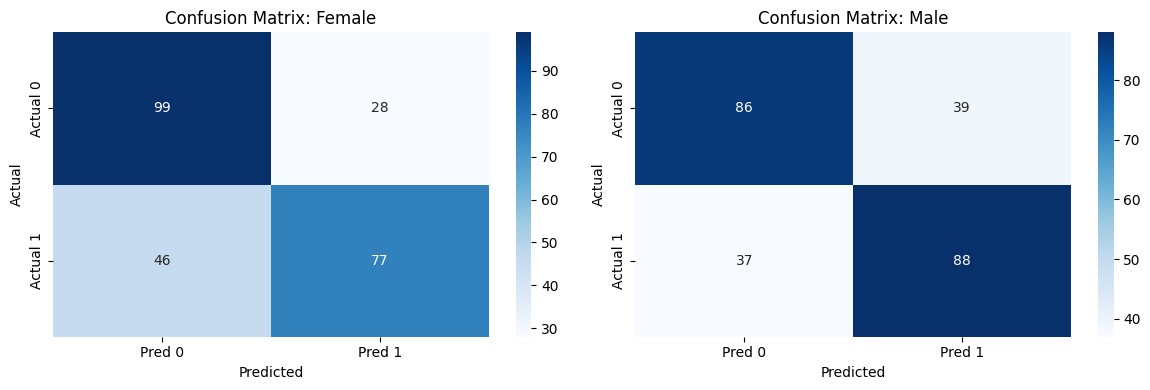

In [34]:
# Side-by-side confusion matrix heatmaps
groups = list(confusion_matrices.keys())
fig, axes = plt.subplots(1, len(groups), figsize=(6 * len(groups), 4))
axes = np.atleast_1d(axes)

for idx, group in enumerate(groups):
    cm = confusion_matrices[group]
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[idx],
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["Actual 0", "Actual 1"],
    )
    axes[idx].set_title(f"Confusion Matrix: {group}")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 10. Calculate overall model metrics

TODO:
- What is overall accuracy, precision, recall (ignoring groups)?
- Compare to per-group metrics to show bias is hidden in aggregates

In [35]:
# Overall metrics (ignoring groups) vs per-group metrics
y_true_all = df["actual_hired"]
y_pred_all = df["model_predicted_hired"]
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1]).ravel()

overall = {
    "accuracy": (tp + tn) / (tp + tn + fp + fn),
    "precision": tp / (tp + fp) if (tp + fp) > 0 else 0.0,
    "recall": tp / (tp + fn) if (tp + fn) > 0 else 0.0,
    "TPR": tp / (tp + fn) if (tp + fn) > 0 else 0.0,
    "FPR": fp / (fp + tn) if (fp + tn) > 0 else 0.0,
    "selection_rate": y_pred_all.mean(),
}

comparison_df = metrics_df[["accuracy", "precision", "recall", "TPR", "FPR", "selection_rate"]].copy()
comparison_df.loc["Overall"] = overall

print("Per-group vs overall performance:")
print(comparison_df.round(3))

print("\nOverall classification report:")
print(classification_report(y_true_all, y_pred_all, digits=3))

Per-group vs overall performance:
         accuracy  precision  recall    TPR    FPR  selection_rate
group                                                             
Female      0.704      0.733   0.626  0.626  0.220           0.420
Male        0.696      0.693   0.704  0.704  0.312           0.508
Overall     0.700      0.711   0.665  0.665  0.266           0.464

Overall classification report:
              precision    recall  f1-score   support

           0      0.690     0.734     0.712       252
           1      0.711     0.665     0.688       248

    accuracy                          0.700       500
   macro avg      0.701     0.700     0.700       500
weighted avg      0.701     0.700     0.700       500



## 11. Impact analysis

TODO:
- Identify which group is disadvantaged (lower TPR = fewer hired)
- Quantify the impact in # of people affected
- Estimate real-world consequence

In [36]:
# Impact analysis: who is disadvantaged and by how much
disadvantaged_group = metrics_df["TPR"].idxmin()
advantaged_group = metrics_df["TPR"].idxmax()

disadv_data = df[df["gender"] == disadvantaged_group].copy()
actual_positive_disadv = int((disadv_data["actual_hired"] == 1).sum())
current_tp_disadv = int(
    ((disadv_data["actual_hired"] == 1) & (disadv_data["model_predicted_hired"] == 1)).sum()
)
current_fn_disadv = int(
    ((disadv_data["actual_hired"] == 1) & (disadv_data["model_predicted_hired"] == 0)).sum()
)

target_tpr = metrics_df.loc[advantaged_group, "TPR"]
expected_tp_if_equal = int(round(target_tpr * actual_positive_disadv))
additional_people_approved_if_equal_tpr = max(0, expected_tp_if_equal - current_tp_disadv)

print(f"Disadvantaged group by TPR: {disadvantaged_group}")
print(f"Advantaged group by TPR: {advantaged_group}")
print(f"Current TPR gap: {(metrics_df['TPR'].max() - metrics_df['TPR'].min()):.2%}")
print(f"Current false negatives in {disadvantaged_group}: {current_fn_disadv}")
print(
    f"Estimated additional qualified {disadvantaged_group} candidates approved if TPR matched {advantaged_group}: "
    f"{additional_people_approved_if_equal_tpr}"
)

print("\nReal-world implication:")
print(
    "Lower TPR means more qualified people in the disadvantaged group are incorrectly rejected, "
    "which can reduce access to jobs and reinforce inequity over time."
)

Disadvantaged group by TPR: Female
Advantaged group by TPR: Male
Current TPR gap: 7.80%
Current false negatives in Female: 46
Estimated additional qualified Female candidates approved if TPR matched Male: 10

Real-world implication:
Lower TPR means more qualified people in the disadvantaged group are incorrectly rejected, which can reduce access to jobs and reinforce inequity over time.


## 12. Mitigation proposal

TODO:
- Propose one bias mitigation strategy (e.g., threshold adjustment, remove correlated features, rebalance training data, etc.)
- Show one example or describe the approach
- Acknowledge tradeoffs and ethical considerations

In [37]:
# Mitigation proposal: equal opportunity style post-processing demo
print("Recommended strategy: fairness-aware thresholding with monitoring.")
print(
    "Use score-based thresholds tuned on a validation set to reduce TPR disparity "
    "while tracking precision/FPR tradeoffs."
)

# This dataset has only binary model outputs (no probabilities), so we simulate a
# simple intervention by flipping a limited number of disadvantaged false negatives
# using interview_score/resume_score as a proxy ranking signal.
simulated_df = df.copy()
needed = additional_people_approved_if_equal_tpr

if needed > 0:
    mask = (
        (simulated_df["gender"] == disadvantaged_group)
        & (simulated_df["actual_hired"] == 1)
        & (simulated_df["model_predicted_hired"] == 0)
    )
    candidates_to_flip = (
        simulated_df[mask]
        .sort_values(["interview_score", "resume_score"], ascending=False)
        .head(needed)
        .index
    )
    simulated_df.loc[candidates_to_flip, "model_predicted_hired"] = 1

sim_metrics = []
for g in metrics_df.index:
    sim_metrics.append(compute_confusion_metrics(simulated_df[simulated_df["gender"] == g], f"{g}_sim"))
sim_metrics_df = pd.DataFrame(sim_metrics).set_index("group")

before_tpr_gap = metrics_df["TPR"].max() - metrics_df["TPR"].min()
after_tpr_gap = sim_metrics_df["TPR"].max() - sim_metrics_df["TPR"].min()

print("\nMitigation simulation summary:")
print(f"TPR gap before: {before_tpr_gap:.2%}")
print(f"TPR gap after:  {after_tpr_gap:.2%}")
print("\nTradeoffs and ethics:")
print("- Reducing TPR disparity can improve fairness for qualified candidates.")
print("- It may change precision/FPR and must be validated for all groups.")
print("- Group-aware intervention can be legally/ethically sensitive and needs governance.")
print("- Do not deploy without stakeholder review, policy alignment, and ongoing audits.")

Recommended strategy: fairness-aware thresholding with monitoring.
Use score-based thresholds tuned on a validation set to reduce TPR disparity while tracking precision/FPR tradeoffs.

Female_sim confusion matrix counts
TP=87, FP=28, FN=36, TN=99
TPR=0.707, FPR=0.220, Precision=0.757, Accuracy=0.744

Male_sim confusion matrix counts
TP=88, FP=39, FN=37, TN=86
TPR=0.704, FPR=0.312, Precision=0.693, Accuracy=0.696

Mitigation simulation summary:
TPR gap before: 7.80%
TPR gap after:  0.33%

Tradeoffs and ethics:
- Reducing TPR disparity can improve fairness for qualified candidates.
- It may change precision/FPR and must be validated for all groups.
- Group-aware intervention can be legally/ethically sensitive and needs governance.
- Do not deploy without stakeholder review, policy alignment, and ongoing audits.


## Analysis Questions

1. What fairness metric is violated (demographic parity, equalized odds, or both)?
2. Which demographic group is disadvantaged and by how much?
3. What is the real-world impact of this bias?
4. What is your recommended mitigation strategy and its tradeoff?
5. Should this model be deployed as-is? Why or why not?

This analysis shows that both demographic parity and equalized odds are violated: the model’s selection rate differs by 8.8 percentage points (Female 42.0% vs Male 50.8%), and equalized-odds gaps are also substantial (TPR gap 7.8 points, FPR gap 9.15 points). The disadvantaged group is Female candidates, who have lower recall/TPR (62.6% vs 70.4%), meaning more qualified women are incorrectly rejected. In practical terms, the model currently produces 46 false negatives for women, and if female TPR matched male TPR, about 10 additional qualified female candidates would be recommended in this sample. A reasonable mitigation is fairness-aware threshold tuning with ongoing monitoring and governance, but the tradeoff is potential shifts in precision/FPR and legal-ethical risk if group-aware adjustments are not carefully justified. Because these disparities are material and affect real hiring outcomes, the model should not be deployed as-is; it should be revised, validated, and audited before production use.

## Final Recommendation Write-Up

1. **Fairness metrics violated:** Both demographic parity and equalized odds are violated.
- Demographic parity gap (selection rate): **8.8 percentage points** (Female 42.0% vs Male 50.8%).
- Equalized odds gaps: **TPR gap 7.8 points** and **FPR gap 9.15 points**.

2. **Disadvantaged group:** **Female candidates** are disadvantaged on opportunity-based fairness.
- Female TPR: **62.6%**
- Male TPR: **70.4%**
- Interpretation: qualified female candidates are more likely to be missed (false negatives).

3. **Estimated impact:**
- Female false negatives: **46** qualified candidates rejected.
- If Female TPR matched Male TPR, about **10 additional qualified female candidates** would be recommended for hire in this sample.

4. **Mitigation strategy and tradeoff:**
- Recommended: fairness-aware threshold tuning and monitoring on validation data.
- In this notebook's simulation, TPR gap drops from **7.8%** to **0.33%**.
- Tradeoff: changing thresholds can affect precision/FPR and may create legal or ethical concerns if group-aware treatment is not carefully governed.

5. **Deployment recommendation:**
- **Do not deploy as-is.**
- Require mitigation, governance review, and continuous fairness auditing before production use.

Both demographic parity and equalized odds are violated in this model: selection rates differ by 8.8 percentage points (Female 42.0% vs Male 50.8%), with additional gaps in TPR (7.8 points) and FPR (9.15 points). Female candidates are the disadvantaged group, with lower TPR (62.6% vs 70.4%), meaning more qualified women are incorrectly rejected; in this sample, that includes 46 false negatives, and closing the TPR gap would approve about 10 additional qualified female candidates. A practical mitigation is fairness-aware threshold tuning with continuous monitoring, but the tradeoff is possible shifts in precision/FPR and legal-ethical risk if group-aware adjustments are not carefully governed. Based on these disparities, the model should not be deployed as-is and should undergo mitigation, policy review, and ongoing fairness audits first.

## Bonus (Optional)

Investigate: If you adjusted the threshold for the disadvantaged group,
what threshold would equalize TPR? What would be the side effects?